# Learning Parametrization with Implicit Neural Representations for Jet Events

This notebook implements an Implicit Neural Representation (INR) model to represent jet events from the ML4SCI quark/gluon dataset.

The goal is to learn a continuous function:

f(x, y, c) → intensity

where:
- x,y are spatial coordinates
- c denotes the detector channel (ECAL, HCAL, Tracks)

To improve the representation of high-frequency structures, we use **Fourier feature positional encoding** before feeding coordinates into the neural network.

We evaluate reconstruction quality using:
- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index (SSIM)

Additionally we analyze reconstruction errors with heatmaps and distribution plots.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5


In [18]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
file_path = "/kaggle/input/datasets/ankushpanjiyar/quark-gluon/quark-gluon_data-set_n139306.hdf5"

with h5py.File(file_path, "r") as f:
    X = f["X_jets"][:]

print("Dataset shape:", X.shape)

Dataset shape: (139306, 125, 125, 3)


In [5]:
event_ids = [0, 10, 25]
events = []
for idx in event_ids:
    e = X[idx].astype(np.float32)
    e /= e.max() + 1e-8
    e = np.transpose(e,(2,0,1))
    events.append(e)

print("Loaded events:", len(events))

Loaded events: 3


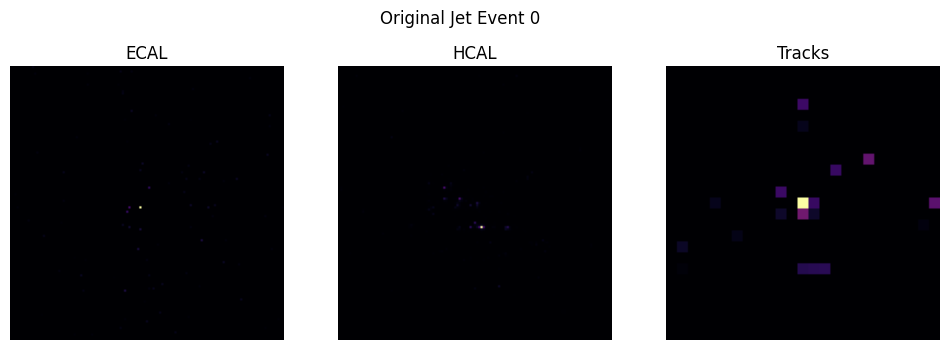

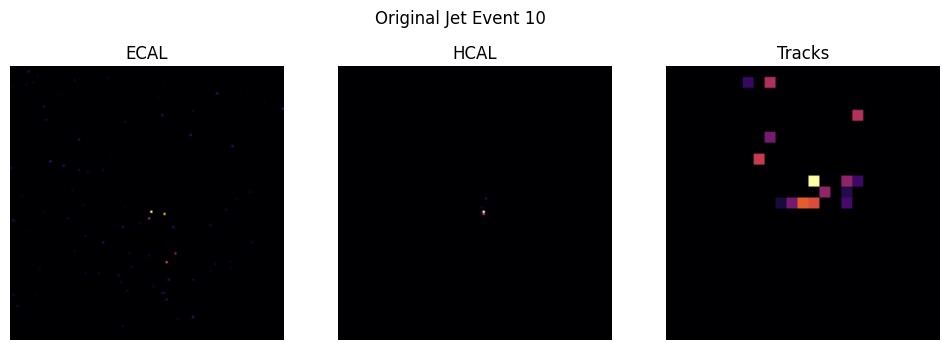

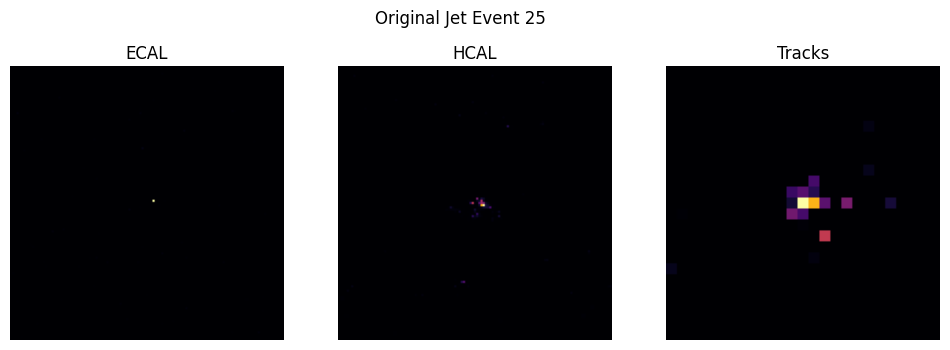

In [6]:
channels = ["ECAL","HCAL","Tracks"]
for e_idx, event in enumerate(events):
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    for i in range(3):
        axes[i].imshow(event[i], cmap="inferno")
        axes[i].set_title(f"{channels[i]}")
        axes[i].axis("off")

    plt.suptitle(f"Original Jet Event {event_ids[e_idx]}")
    plt.show()

In [7]:
def create_coordinate_dataset(event):
    C,H,W = event.shape
    coords = []
    values = []
    for c in range(C):
        for i in range(H):
            for j in range(W):
                x = i/H
                y = j/W
                channel = c/3

                coords.append([x,y,channel])
                values.append(event[c,i,j])

    coords = torch.tensor(coords).float()
    values = torch.tensor(values).float().unsqueeze(1)

    return coords, values

In [8]:
class FourierFeatures(nn.Module):

    def __init__(self, in_dim, num_features=64, scale=10):
        super().__init__()
        B = torch.randn((in_dim, num_features)) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

In [9]:
class INR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoding = FourierFeatures(3,64)
        self.net = nn.Sequential(
            nn.Linear(128,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoding(x)
        return self.net(x)

In [10]:
def train_inr(event, epochs=3000):
    coords, values = create_coordinate_dataset(event)
    coords = coords.to(device)
    values = values.to(device)
    model = INR().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    loss_history = []
    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()
        preds = model(coords)
        loss = criterion(preds, values)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    return model, coords, values, loss_history

In [11]:
results = []
for idx, event in enumerate(events):
    print("Training INR for event:", event_ids[idx])
    model, coords, values, loss_history = train_inr(event)
    with torch.no_grad():
        recon = model(coords).cpu().numpy()
    recon = recon.reshape(3,125,125)
    results.append((event, recon, loss_history))

Training INR for event: 0


100%|██████████| 3000/3000 [01:01<00:00, 48.68it/s]


Training INR for event: 10


100%|██████████| 3000/3000 [01:06<00:00, 44.87it/s]


Training INR for event: 25


100%|██████████| 3000/3000 [01:07<00:00, 44.75it/s]


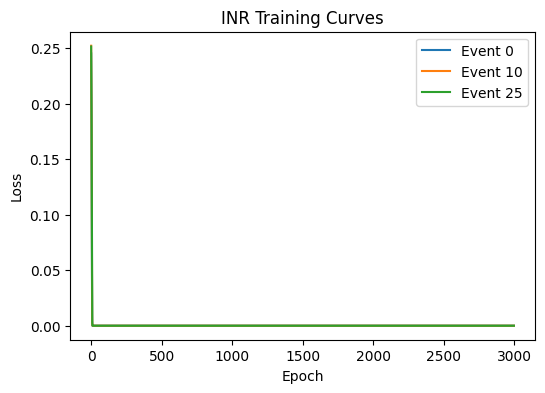

In [12]:
plt.figure(figsize=(6,4))
for i,(event,recon,loss_history) in enumerate(results):
    plt.plot(loss_history,label=f"Event {event_ids[i]}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("INR Training Curves")
plt.legend()
plt.show()

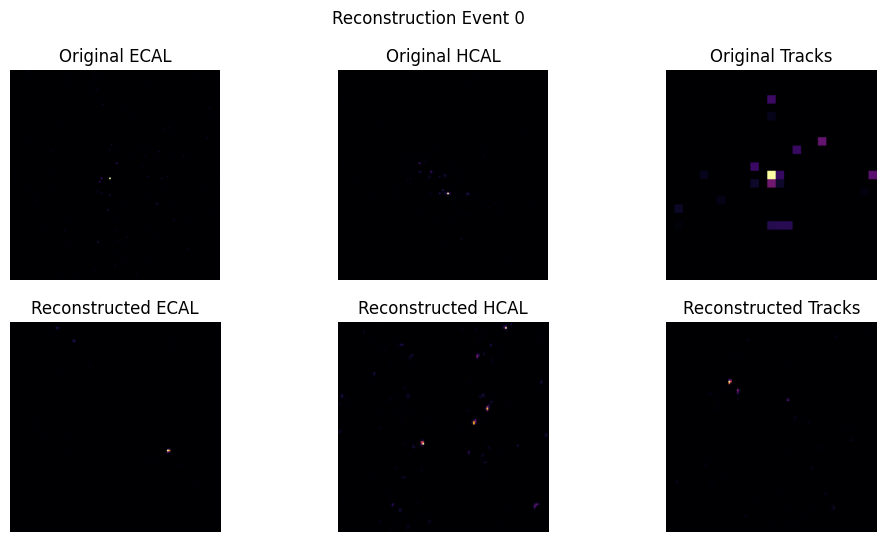

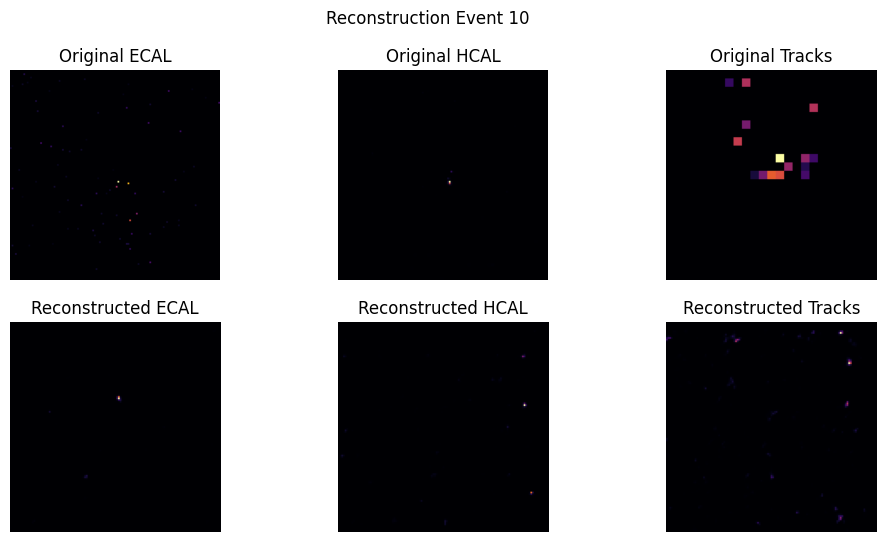

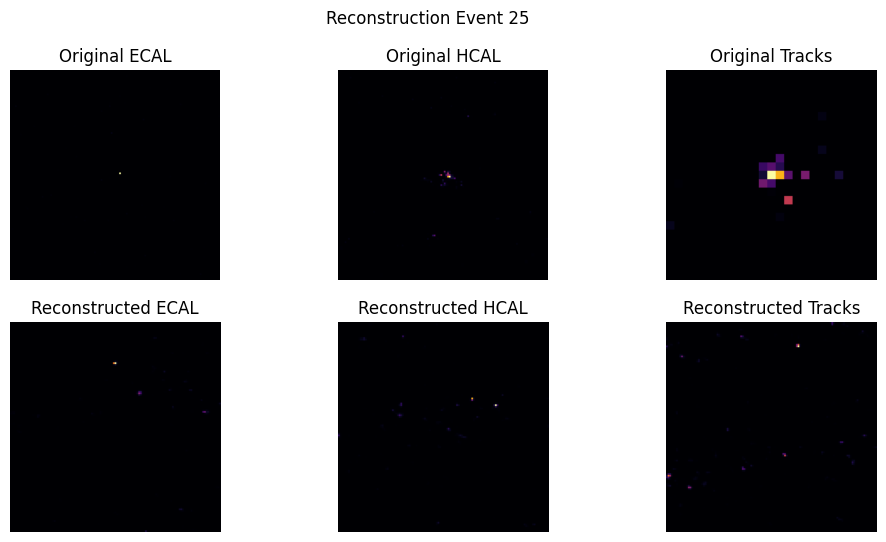

In [13]:
for idx,(event,recon,_) in enumerate(results):

    fig,axes = plt.subplots(2,3, figsize=(12,6))

    for i in range(3):

        axes[0,i].imshow(event[i], cmap="inferno")
        axes[0,i].set_title(f"Original {channels[i]}")
        axes[0,i].axis("off")

        axes[1,i].imshow(recon[i], cmap="inferno")
        axes[1,i].set_title(f"Reconstructed {channels[i]}")
        axes[1,i].axis("off")
    plt.suptitle(f"Reconstruction Event {event_ids[idx]}")

    plt.show()

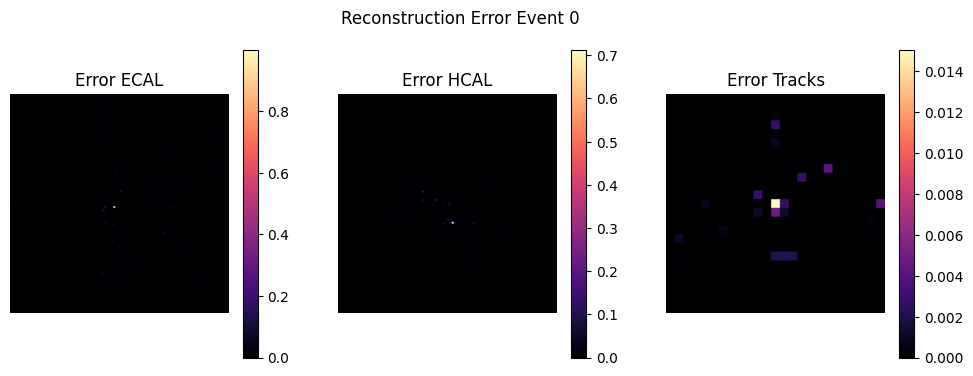

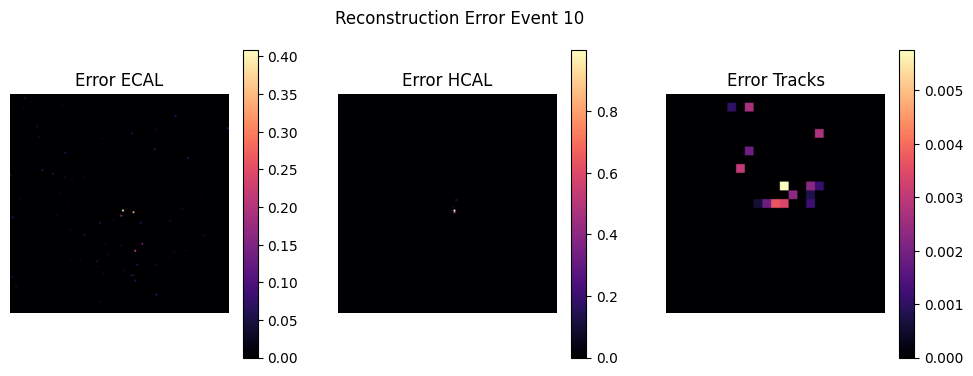

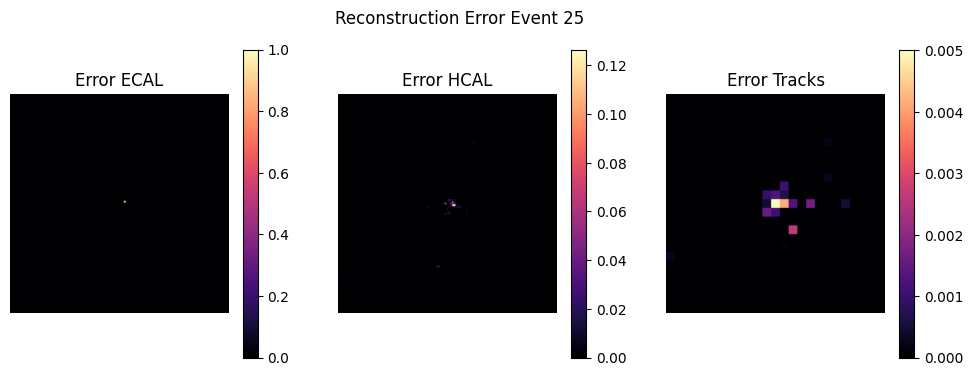

In [14]:
for idx,(event,recon,_) in enumerate(results):

    fig,axes = plt.subplots(1,3, figsize=(12,4))

    for i in range(3):
        error = np.abs(event[i]-recon[i])
        im = axes[i].imshow(error, cmap="magma")
        axes[i].set_title(f"Error {channels[i]}")
        axes[i].axis("off")
        plt.colorbar(im, ax=axes[i])
    plt.suptitle(f"Reconstruction Error Event {event_ids[idx]}")

    plt.show()

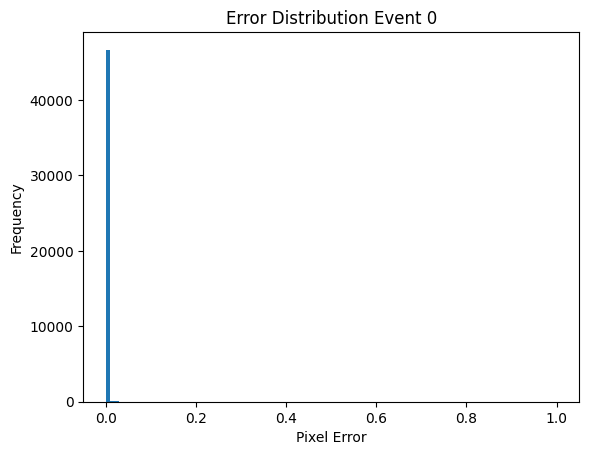

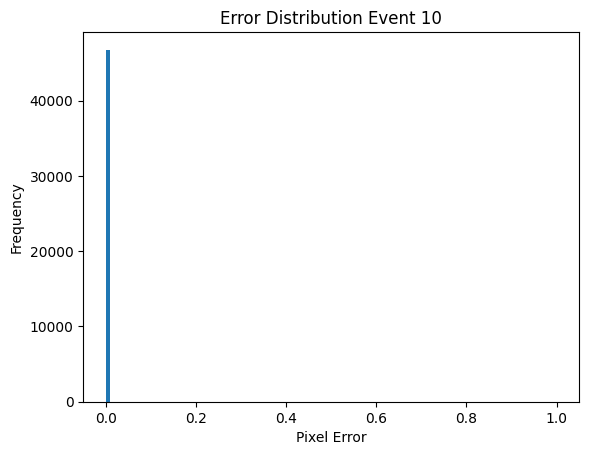

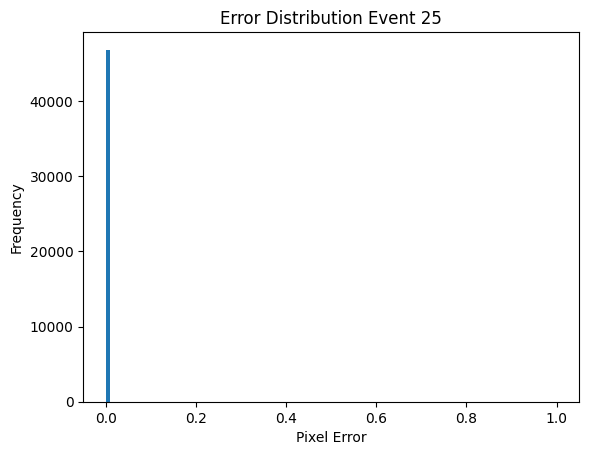

In [15]:
for idx,(event,recon,_) in enumerate(results):
    errors = (event-recon).flatten()
    plt.hist(errors, bins=100)
    plt.title(f"Error Distribution Event {event_ids[idx]}")
    plt.xlabel("Pixel Error")
    plt.ylabel("Frequency")
    plt.show()

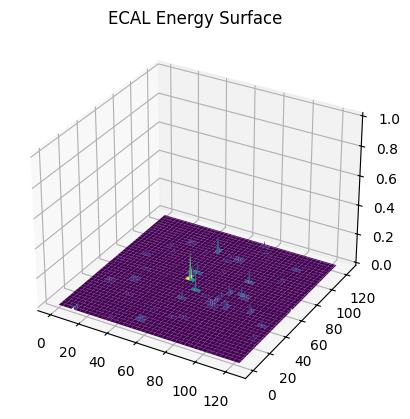

In [16]:
Xgrid, Ygrid = np.meshgrid(range(125), range(125))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xgrid, Ygrid, events[0][0], cmap="viridis")
plt.title("ECAL Energy Surface")
plt.show()

In [19]:
metrics = []
for idx,(event,recon,_) in enumerate(results):
    for i,name in enumerate(channels):
        mse = np.mean((event[i]-recon[i])**2)
        p = psnr(event[i], recon[i], data_range=1)
        s = ssim(event[i], recon[i], data_range=1)
        metrics.append([event_ids[idx], name, mse, p, s])

df = pd.DataFrame(metrics, columns=["Event","Channel","MSE","PSNR","SSIM"])

df

,Event,Channel,MSE,PSNR,SSIM
0,0,ECAL,7.996559e-05,40.970968,0.980113
1,0,HCAL,4.374865e-05,43.590353,0.984673
2,0,Tracks,5.287816e-07,62.767237,0.997889
3,10,ECAL,3.406538e-05,44.676868,0.979664
4,10,HCAL,8.559547e-05,40.675492,0.993710
5,10,Tracks,1.665874e-07,67.783579,0.999188
6,25,ECAL,6.452694e-05,41.902589,0.995856
7,25,HCAL,2.956250e-06,55.292588,0.996228
8,25,Tracks,9.925169e-08,70.032621,0.999384


## Discussion

The INR model successfully learns a continuous representation of jet events across detector channels.  
Fourier positional encoding allows the network to capture fine spatial structures present in calorimeter images.

Across multiple events, the reconstructed images preserve the overall energy distribution patterns observed in the original data. Error heatmaps indicate that most reconstruction errors occur in regions with extremely low energy deposits, which are inherently difficult to approximate.

Overall, the INR framework provides a compact and continuous parametrization of jet events that could be useful for tasks such as anomaly detection or generative modeling in particle physics.

## Experiment Summary

Model: Implicit Neural Representation with Fourier positional encoding  
Input: Coordinate representation (x, y, channel)  
Architecture: 4-layer MLP (256 hidden units)  
Training: Adam optimizer, 3000 epochs  
Evaluation Metrics: MSE, PSNR, SSIM  

Results show high structural similarity between original and reconstructed jet events, demonstrating the capability of implicit neural representations to model complex detector data.